### <center>**Exploratory Data Analysis (EDA)**</center>

#### **ITAR Student Performance Dataset**

Exploratory Data Analysis (EDA) is the process of understanding a dataset before building a Machine Learning model.

In this notebook, we will move from **individual features** to **relationships between features and the target variable**.

##### **EDA Workflow**

```text
Cleaned Dataset
      ↓
Dataset Overview
      ↓
Descriptive Statistics
      ↓
Univariate Analysis
      ↓
Bivariate Analysis
      ↓
Correlation Analysis
      ↓
Feature–Target Relationships
      ↓
EDA Findings
      ↓
Machine Learning Preparation
```

> **Important:** Visualization supports analysis; it does not replace statistical reasoning or domain knowledge.


#### **Learning Objectives**

By the end of this notebook, you should be able to:

- Understand the purpose of Exploratory Data Analysis.
- Identify numerical and categorical features.
- Identify a suitable target variable for a prediction problem.
- Calculate and interpret descriptive statistics.
- Analyze numerical and categorical features individually.
- Study relationships between numerical features and the target.
- Calculate and visualize correlations.
- Identify potentially useful features for further Machine Learning analysis.
- Distinguish **association/correlation** from **causation**.


#### **1. Important EDA Concepts**

| Term | Meaning |
|------|---------|
| **Dataset** | A collection of observations used for analysis or Machine Learning. |
| **Feature** | An input variable that may be used to make predictions. |
| **Target Variable** | The output variable that a Machine Learning model is designed to predict. |
| **Numerical Feature** | A feature represented by numerical values, such as age or marks. |
| **Categorical Feature** | A feature represented by categories or labels, such as gender or department. |
| **Distribution** | The way values are spread across observations. |
| **Outlier** | An observation that is unusually high or low compared with the rest of the data. |
| **Relationship** | The way two variables change in relation to each other. |
| **Correlation** | A numerical measure of the strength and direction of a linear relationship between numerical variables. |

##### **EDA and Machine Learning**

EDA helps us understand the data before modeling. It can reveal:

- unusual observations,
- imbalanced categories,
- patterns and trends,
- possible relationships with the target,
- variables that may require further investigation.

> EDA does **not** automatically decide which features should be used in the final model. Feature selection should also consider domain knowledge, data leakage, multicollinearity, model requirements, and validation results.


#### **2. Import Required Libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display plots inside the notebook

# Improve the default Seaborn appearance
sns.set_theme(style="whitegrid")


#### **3. Load the Cleaned Dataset**

This notebook works with the cleaned version of the ITAR Student Performance Dataset.


In [2]:
# Load the cleaned dataset
df = pd.read_csv("../datasets/cleaned/student_performance_cleaned.csv")

##### **3.1 First Five Records**

In [3]:
df.head()

,student_id,full_name,gender,age,department,semester,marks,attendance_percentage,city,admission_date,email,scholarship,tuition_fee,admission_year,admission_month,admission_day,admission_day_name
0,2024001,Muhammad Khan,male,20.0,SE,4,67.0,80.8,Bannu,2024-01-22,muhammad.khan2024001@itar.edu.pk,Yes,15000.0,2024.0,1.0,22.0,Monday
1,2024002,Ali Khan,male,23.0,DS,6,77.0,86.6,Kohat,2024-04-30,ali.khan2024002@itar.edu.pk,No,30000.0,2024.0,4.0,30.0,Tuesday
2,2024003,Ahmad Khan,male,18.0,CS,1,70.0,85.1,Peshawar,2024-12-08,ahmad.khan2024003@itar.edu.pk,No,50000.0,2024.0,12.0,8.0,Sunday
3,2024004,Hamza Khan,male,19.0,DS,2,71.0,85.2,Bannu,NaN,hamza.khan2024004@itar.edu.pk,No,30000.0,NaN,NaN,NaN,NaN
4,2024005,Abdullah Khan,male,18.0,AI,1,82.0,87.1,Mardan,2024-01-01,abdullah.khan2024005@itar.edu.pk,Yes,25000.0,2024.0,1.0,1.0,Monday


##### **3.2 Dataset Dimensions**

In [4]:
df.shape

(145, 17)

##### **3.3 Dataset Structure**

Before analyzing individual variables, inspect the column names and data types.


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 145 entries, 0 to 144
Data columns (total 17 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   student_id             145 non-null    int64  
 1   full_name              145 non-null    str    
 2   gender                 145 non-null    str    
 3   age                    145 non-null    float64
 4   department             145 non-null    str    
 5   semester               145 non-null    int64  
 6   marks                  145 non-null    float64
 7   attendance_percentage  145 non-null    float64
 8   city                   145 non-null    str    
 9   admission_date         139 non-null    str    
 10  email                  145 non-null    str    
 11  scholarship            145 non-null    str    
 12  tuition_fee            145 non-null    float64
 13  admission_year         139 non-null    float64
 14  admission_month        139 non-null    float64
 15  admission_day    

#### **4. Descriptive Statistics**

Descriptive statistics provide a numerical summary of the dataset.

For numerical variables, `describe()` provides:

- count
- mean
- standard deviation
- minimum
- first quartile (25%)
- median (50%)
- third quartile (75%)
- maximum


In [6]:
df.describe()

,student_id,age,semester,marks,attendance_percentage,tuition_fee,admission_year,admission_month,admission_day
count,1.450000e+02,145.000000,145.000000,145.000000,145.000000,145.000000,139.0,139.000000,139.000000
mean,2.024073e+06,21.124138,4.082759,78.903959,85.595862,27068.965517,2024.0,6.525180,15.194245
std,4.200198e+01,2.201271,2.222059,11.456595,8.912545,10778.486271,0.0,3.606216,9.319512
min,2.024001e+06,18.000000,1.000000,12.000000,18.000000,15000.000000,2024.0,1.000000,1.000000
25%,2.024037e+06,19.000000,2.000000,73.000000,84.800000,15000.000000,2024.0,3.000000,7.000000
50%,2.024073e+06,21.000000,4.000000,80.000000,87.100000,30000.000000,2024.0,7.000000,14.000000
75%,2.024109e+06,23.000000,6.000000,86.000000,89.100000,30000.000000,2024.0,10.000000,24.000000
max,2.024145e+06,25.000000,8.000000,98.000000,94.900000,50000.000000,2024.0,12.000000,31.000000


#### **5. Univariate Analysis**

##### **5.1 Target Variable - Marks**

For this notebook, we use **Marks** as the target variable.

The target variable is the value that a Machine Learning model would be designed to predict.

For a marks-prediction problem:

```text
Target
  ↓
marks

Potential Features
  ↓
age
gender
department
semester
attendance_percentage
tuition_fee
...
```

> A column should not be used as a feature merely because it exists in the dataset. Its meaning, availability at prediction time, and relationship to the target must be considered.


##### **5.1.1 Target Summary Statistics**

In [7]:
df['marks'].describe()

count    145.000000
mean      78.903959
std       11.456595
min       12.000000
25%       73.000000
50%       80.000000
75%       86.000000
max       98.000000
Name: marks, dtype: float64

##### **5.1.2 Target Distribution**

Distribution describes how the values of a variable are spread across the observations

##### **Questions to consider**

- Where are most observations concentrated?
- Is the distribution approximately symmetric?
- Are there unusually high or low observations?
- Is the target spread narrow or wide?


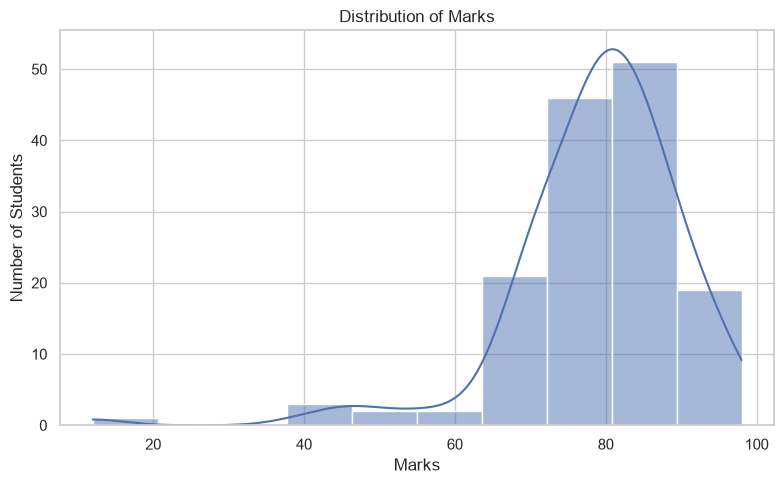

In [8]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x=df['marks'],
    bins=10,
    kde=True
)

plt.title("Distribution of Marks")
plt.xlabel("Marks")
plt.ylabel("Number of Students")
plt.tight_layout()
plt.show()


##### **5.1.3 Target Box Plot**

A box plot provides a compact view of:

- median,
- quartiles,
- overall spread,
- potential statistical outliers.

> A statistical outlier is not automatically an error. It should be investigated before any decision is made to remove or modify it.


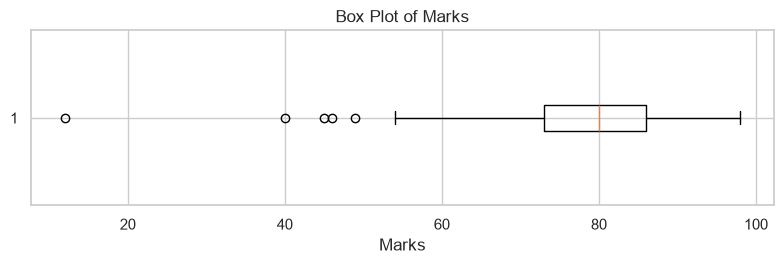

In [9]:
plt.figure(figsize=(8, 2.8))

plt.boxplot(
    df['marks'],
    orientation="horizontal"
)

plt.title("Box Plot of Marks")
plt.xlabel("Marks")
plt.tight_layout()
plt.show()


#### **5.2 Numerical Features**

For this dataset, we will examine important numerical variables individually:

- Age
- Attendance Percentage
- Tuition Fee

We will use descriptive statistics and visualizations to understand their distributions.


##### **5.2.1 Age Distribution**

In [10]:
df["age"].describe()

count    145.000000
mean      21.124138
std        2.201271
min       18.000000
25%       19.000000
50%       21.000000
75%       23.000000
max       25.000000
Name: age, dtype: float64

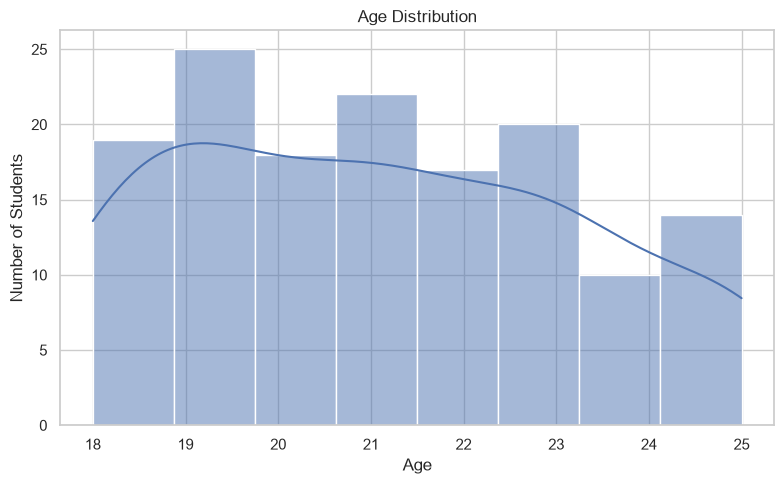

In [11]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="age",
    bins=8,
    kde=True
)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Students")
plt.tight_layout()
plt.show()


##### **5.2.2 Attendance Percentage Distribution**

In [12]:
df["attendance_percentage"].describe()

count    145.000000
mean      85.595862
std        8.912545
min       18.000000
25%       84.800000
50%       87.100000
75%       89.100000
max       94.900000
Name: attendance_percentage, dtype: float64

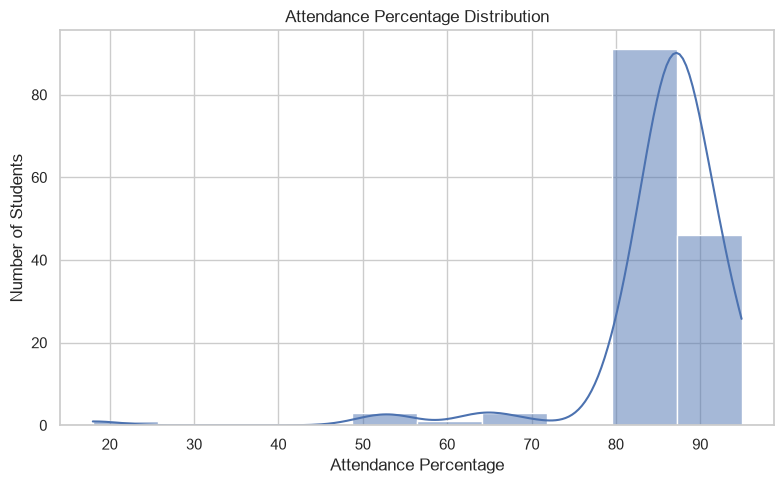

In [13]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="attendance_percentage",
    bins=10,
    kde=True
)

plt.title("Attendance Percentage Distribution")
plt.xlabel("Attendance Percentage")
plt.ylabel("Number of Students")
plt.tight_layout()
plt.show()


##### **5.2.3 Tuition Fee Distribution**

In [14]:
df["tuition_fee"].describe()

count      145.000000
mean     27068.965517
std      10778.486271
min      15000.000000
25%      15000.000000
50%      30000.000000
75%      30000.000000
max      50000.000000
Name: tuition_fee, dtype: float64

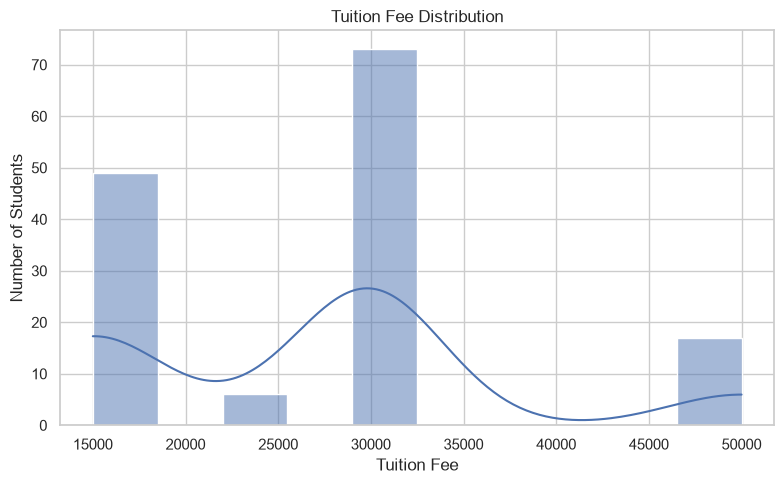

In [15]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="tuition_fee",
    bins=10,
    kde=True
)

plt.title("Tuition Fee Distribution")
plt.xlabel("Tuition Fee")
plt.ylabel("Number of Students")
plt.tight_layout()
plt.show()


#### **5.3 Categorical Feature Analysis**

Categorical variables contain labels or categories rather than continuous numerical measurements.

We will examine:

- Gender
- Department
- Semester

Frequency counts tell us how observations are distributed across categories.


##### **5.3.1 Gender Distribution**

In [16]:
df["gender"].value_counts(dropna=False)

gender
male      90
female    55
Name: count, dtype: int64

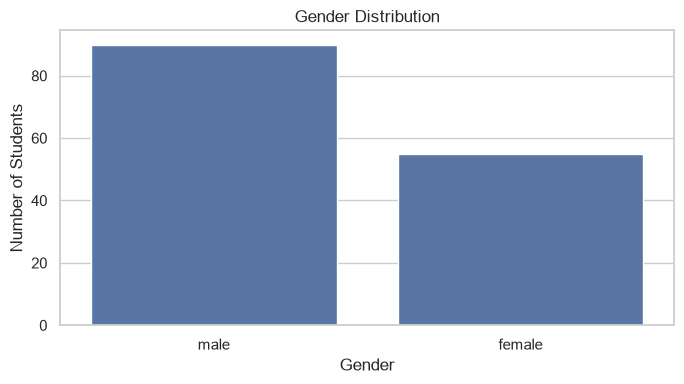

In [17]:
plt.figure(figsize=(7, 4))

sns.countplot(
    data=df,
    x="gender",
    order=df["gender"].value_counts().index
)

plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Number of Students")
plt.tight_layout()
plt.show()


##### **5.3.2 Department Distribution**

In [18]:
df["department"].value_counts(dropna=False)

department
CS    36
IT    34
SE    29
AI    27
DS    19
Name: count, dtype: int64

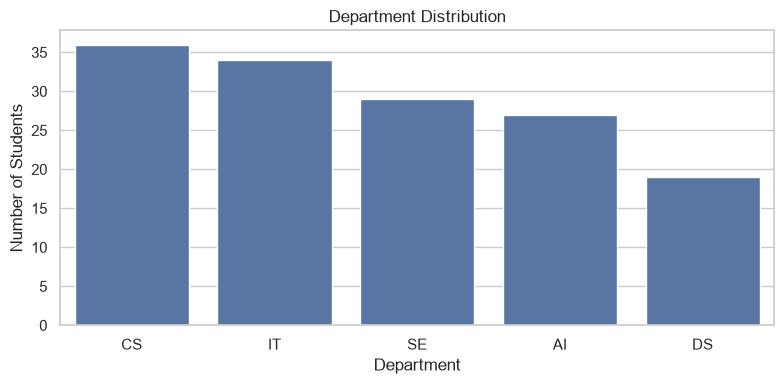

In [19]:
plt.figure(figsize=(8, 4))

sns.countplot(
    data=df,
    x="department",
    order=df["department"].value_counts().index
)

plt.title("Department Distribution")
plt.xlabel("Department")
plt.ylabel("Number of Students")
plt.tight_layout()
plt.show()


##### **5.3.3 Semester Distribution**

In [20]:
df["semester"].value_counts(dropna=False).sort_index()

semester
1    23
2    20
3    20
4    22
5    18
6    15
7    15
8    12
Name: count, dtype: int64

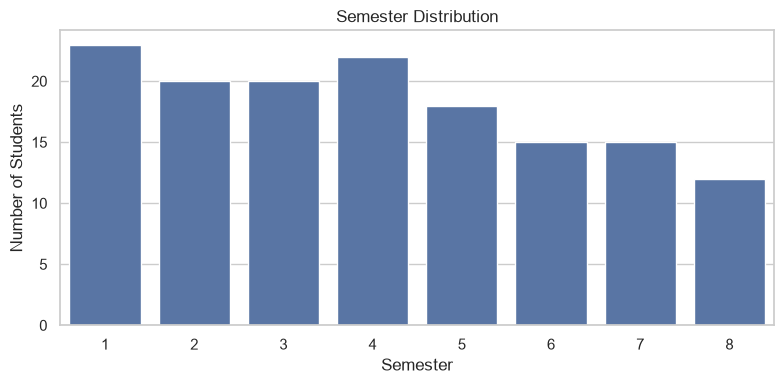

In [21]:
plt.figure(figsize=(8, 4))

sns.countplot(
    data=df,
    x="semester",
    order=sorted(df["semester"].dropna().unique())
)

plt.title("Semester Distribution")
plt.xlabel("Semester")
plt.ylabel("Number of Students")
plt.tight_layout()
plt.show()


#### **6. Bivariate Analysis**

**Bivariate analysis** examines two variables at the same time.

Because the current prediction problem uses **Marks** as the target, we will investigate how selected numerical features relate to Marks.

We will examine:

1. Age vs Marks
2. Attendance Percentage vs Marks
3. Tuition Fee vs Marks

Scatter plots help us visually inspect the direction, strength, and form of relationships.


##### **6.1 Age vs Marks**

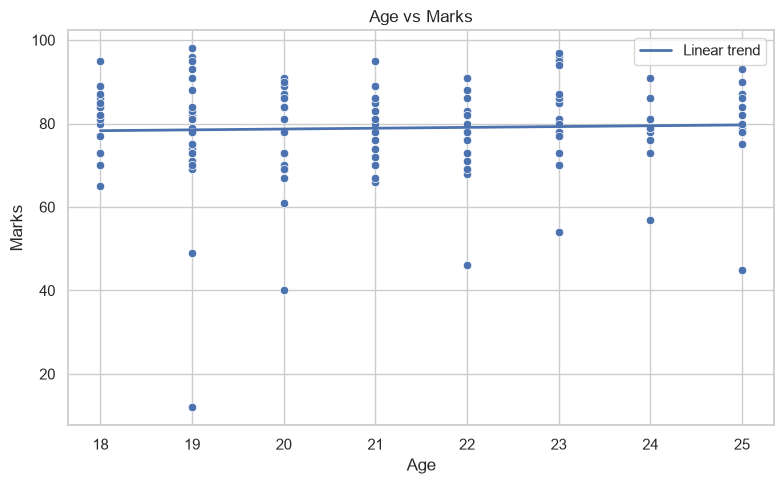

In [22]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="age",
    y="marks"
)

# Add a simple linear trend line
x = df["age"].to_numpy()
y = df['marks'].to_numpy()
slope, intercept = np.polyfit(x, y, 1)

x_line = np.linspace(x.min(), x.max(), 100)
y_line = slope * x_line + intercept

plt.plot(
    x_line,
    y_line,
    linewidth=2,
    label="Linear trend"
)

plt.title("Age vs Marks")
plt.xlabel("Age")
plt.ylabel("Marks")
plt.legend()
plt.tight_layout()
plt.show()


##### **6.2 Attendance Percentage vs Marks**

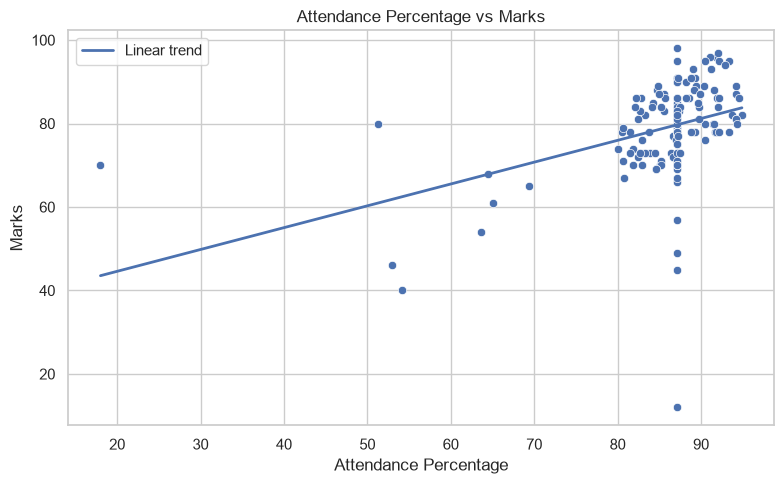

In [23]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="attendance_percentage",
    y='marks'
)

x = df["attendance_percentage"].to_numpy()
y = df['marks'].to_numpy()
slope, intercept = np.polyfit(x, y, 1)

x_line = np.linspace(x.min(), x.max(), 100)
y_line = slope * x_line + intercept

plt.plot(
    x_line,
    y_line,
    linewidth=2,
    label="Linear trend"
)

plt.title("Attendance Percentage vs Marks")
plt.xlabel("Attendance Percentage")
plt.ylabel("Marks")
plt.legend()
plt.tight_layout()
plt.show()


##### **6.3 Tuition Fee vs Marks**

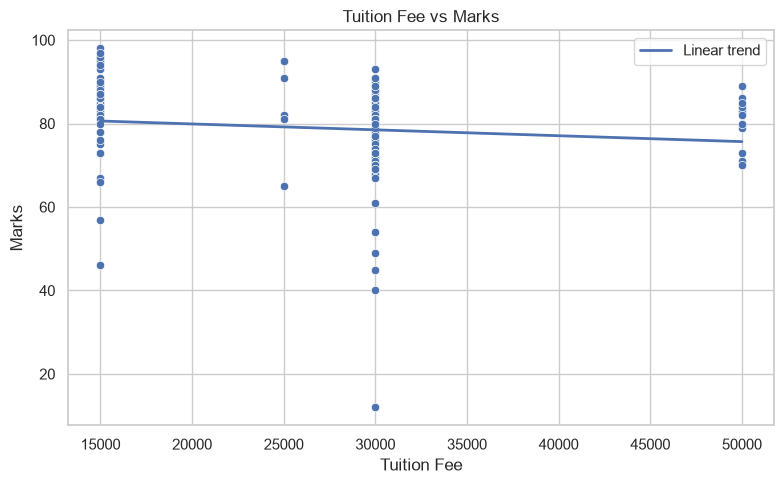

In [24]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="tuition_fee",
    y='marks'
)

x = df["tuition_fee"].to_numpy()
y = df['marks'].to_numpy()
slope, intercept = np.polyfit(x, y, 1)

x_line = np.linspace(x.min(), x.max(), 100)
y_line = slope * x_line + intercept

plt.plot(
    x_line,
    y_line,
    linewidth=2,
    label="Linear trend"
)

plt.title("Tuition Fee vs Marks")
plt.xlabel("Tuition Fee")
plt.ylabel("Marks")
plt.legend()
plt.tight_layout()
plt.show()


##### **Interpreting Bivariate Relationships**

When looking at a scatter plot, ask:

- Does the target generally increase as the feature increases?
- Does the target generally decrease as the feature increases?
- Are the points widely scattered?
- Is there an approximately linear pattern?
- Are there unusual observations?
- Could another variable explain the apparent relationship?

##### **Relationship Types**

| Pattern | General Interpretation |
|--------|------------------------|
| Upward trend | Positive association |
| Downward trend | Negative association |
| Widely scattered | Weak or unclear association |
| No visible pattern | Little apparent linear association |

> **Important:** A visible relationship does not prove that one variable causes the other.


#### **7. Correlation Analysis**

Correlation provides a numerical summary of the **direction and strength of a linear relationship** between numerical variables.

The Pearson correlation coefficient ranges from **-1 to +1**:

| Correlation | General Interpretation |
|------------|------------------------|
| Close to +1 | Strong positive linear relationship |
| Close to 0 | Weak or no linear relationship |
| Close to -1 | Strong negative linear relationship |

A useful interpretation is:

```text
Positive correlation
Feature ↑  →  Target tends to ↑

Negative correlation
Feature ↑  →  Target tends to ↓

Near-zero correlation
No strong linear pattern detected
```

> Correlation measures linear association. A low correlation does not prove that no relationship exists; the relationship may be nonlinear.


##### **7.1 Numerical Correlation Matrix**

We should not blindly calculate correlations for every numeric-looking column.

For example, `student_id` is numeric in appearance but represents an identifier, not a meaningful measurement.

Therefore, we explicitly select analytical numerical variables.


In [25]:
numerical_features = [
    "age",
    "semester",
    "marks",
    "attendance_percentage",
    "tuition_fee"
]

correlation_matrix = df[numerical_features].corr()

correlation_matrix


,age,semester,marks,attendance_percentage,tuition_fee
age,1.000000,0.915036,0.037938,0.011636,-0.313833
semester,0.915036,1.000000,0.028971,0.035819,-0.394283
marks,0.037938,0.028971,1.000000,0.406958,-0.132791
attendance_percentage,0.011636,0.035819,0.406958,1.000000,-0.153924
tuition_fee,-0.313833,-0.394283,-0.132791,-0.153924,1.000000


##### **7.2 Correlation Heatmap**

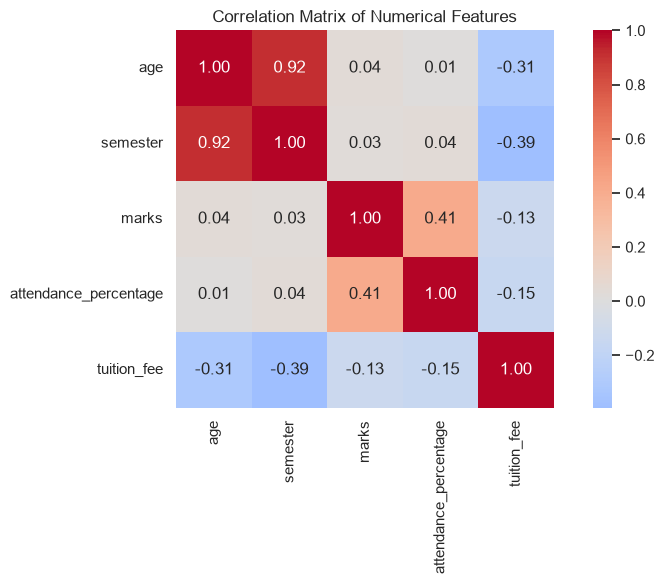

In [26]:
plt.figure(figsize=(9, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True
)

plt.title("Correlation Matrix of Numerical Features")
plt.tight_layout()
plt.show()


##### **7.3 Feature–Target Correlation**

For the current problem, Marks is the target.

We can inspect how the selected numerical features correlate with Marks.


In [27]:
marks_correlation = (
    correlation_matrix['marks']
    .sort_values(ascending=False)
)

marks_correlation


marks                    1.000000
attendance_percentage    0.406958
age                      0.037938
semester                 0.028971
tuition_fee             -0.132791
Name: marks, dtype: float64

##### **7.4 Rank Potential Numerical Predictors**

The target itself will naturally have a correlation of `1.00` with itself, so it should be excluded when ranking candidate predictors.


In [28]:
feature_target_correlation = (
    marks_correlation
    .drop('marks')
    .sort_values(key=lambda s: s.abs(), ascending=False)
)

feature_target_correlation


attendance_percentage    0.406958
tuition_fee             -0.132791
age                      0.037938
semester                 0.028971
Name: marks, dtype: float64

##### **7.5 Illustrative Correlation Screening**

As a simple educational screening example, we can identify numerical features whose **absolute correlation with Marks is greater than 0.30**.

> **Important:** `0.30` is only an illustrative threshold in this notebook. It is not a universal rule for feature selection. A professional feature-selection decision should also consider domain knowledge, sample size, multicollinearity, data leakage, nonlinear relationships, and model validation.


In [29]:
screening_threshold = 0.30

screened_features = feature_target_correlation[
    feature_target_correlation.abs() > screening_threshold
]

screened_features


attendance_percentage    0.406958
Name: marks, dtype: float64

#### **8. Correlation Does Not Prove Causation**

This is one of the most important ideas in data analysis.

If two variables are correlated, it means that they vary together in some way. It does **not** prove that one variable causes the other.

For example:

```text
Attendance  ↔  Marks
```

If attendance and marks are positively correlated, we may say:

> Students with higher attendance tend to have higher marks in this dataset.

We should **not** automatically say:

> Higher attendance causes higher marks.

Causal conclusions require an appropriate research design and additional evidence.


#### **9. EDA Summary**

In this notebook, we completed the main exploratory steps:

##### **Dataset Understanding**
- Loaded the cleaned dataset.
- Inspected the first records and dataset dimensions.
- Reviewed the dataset structure.
- Examined descriptive statistics.

##### **Univariate Analysis**
- Studied the distribution of Marks.
- Examined Age, Attendance Percentage, and Tuition Fee.
- Examined categorical distributions for Gender, Department, and Semester.
- Used histograms, box plots, and count plots.

##### **Bivariate Analysis**
- Studied Age vs Marks.
- Studied Attendance Percentage vs Marks.
- Studied Tuition Fee vs Marks.
- Added simple linear trend lines to support visual interpretation.

##### **Correlation Analysis**
- Built a correlation matrix using relevant numerical variables.
- Visualized the matrix with a heatmap.
- Ranked numerical features according to their correlation with Marks.
- Demonstrated an illustrative correlation-based screening rule.

##### **Key Principle**

> **EDA helps us understand the data; it does not replace Machine Learning validation.**

The next stage is to prepare the selected features appropriately for model training, while avoiding data leakage and ensuring that preprocessing is learned from the training data only.


#### **10. Final EDA Checklist**

Before moving to Machine Learning, ask:

- [ ] Do I understand the dataset structure?
- [ ] Have I identified the target variable?
- [ ] Have I examined numerical distributions?
- [ ] Have I examined categorical distributions?
- [ ] Have I investigated important relationships?
- [ ] Have I checked correlations?
- [ ] Have I investigated unusual observations?
- [ ] Have I avoided treating correlation as causation?
- [ ] Have I identified possible data leakage?
- [ ] Do I know which columns should **not** be model features?

If these questions have been addressed, the dataset is ready to move into the **feature preparation and Machine Learning workflow**.


#### **Reproducibility Note**

This notebook intentionally contains **no saved execution outputs**. Run the notebook from top to bottom after placing the cleaned CSV at:

```text
datasets/
└── cleaned/
    └── student_performance_cleaned.csv
```

Recommended repository structure:

```text
ITAR-Student-Performance/
│
├── datasets/
│   └── cleaned/
│       └── student_performance_cleaned.csv
│
├── notebooks/
│   └── 06-Exploratory Data Analysis.ipynb
│
└── README.md
```
